In [1]:
import requests
import csv
import time
from datetime import datetime, timezone, timedelta
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

In [2]:
API_URL   = "https://api.phishstats.info/api/phishing"
CSV_FILE  = "phishing_data.csv"
PAGE_SIZE = 20
WINDOW_H  = 12


def extract_brand(record):
    title = (record.get("title") or "").strip()
    if title and title not in (".", "Home", "None"):
        return title
    return "Unknown"


def collect_window(window_hours=WINDOW_H):
    since = datetime.now(timezone.utc) - timedelta(hours=window_hours)
    collected, seen_ids, page = [], set(), 0

    while True:
        try:
            resp = requests.get(
                API_URL,
                params={"_sort": "-id", "_size": PAGE_SIZE, "_p": page},
                timeout=25,
            )
            resp.raise_for_status()
            records = resp.json()
        except Exception as e:
            print(f"ошибка стр. {page}: {e}")
            time.sleep(3)
            continue

        if not records:
            break

        stop = False
        for r in records:
            rid = r.get("id") or 0
            if rid in seen_ids:
                continue
            seen_ids.add(rid)
            date_str = r.get("date") or ""
            if date_str:
                try:
                    if datetime.fromisoformat(date_str.replace("Z", "+00:00")) < since:
                        stop = True
                        break
                except ValueError:
                    pass
            collected.append(r)

        if stop or len(records) < PAGE_SIZE:
            break
        page += 1
        time.sleep(0.5)

    return collected

In [3]:
start_time = datetime.now(timezone.utc)

records = collect_window()

finish_time = datetime.now(timezone.utc)

ошибка стр. 4: HTTPSConnectionPool(host='api.phishstats.info', port=443): Read timed out. (read timeout=25)


ошибка стр. 4: HTTPSConnectionPool(host='api.phishstats.info', port=443): Read timed out. (read timeout=25)


In [4]:
seen_urls, rows = set(), []

for r in records:
    url = (r.get("url") or "").strip()
    if not url or url in seen_urls:
        continue
    seen_urls.add(url)
    rows.append({
        "id":    r.get("id"),
        "url":   url,
        "brand": extract_brand(r),
        "date":  r.get("date"),
    })

with open(CSV_FILE, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["id", "url", "brand", "date"])
    writer.writeheader()
    writer.writerows(rows)

df = pd.DataFrame(rows)
df["date"] = pd.to_datetime(df["date"], utc=True)
display(df.head(10))

,id,url,brand,date
0,11850214,https://gls-grouptu.cfd/pts,Unknown,2026-04-22 12:36:13+00:00
1,11850213,https://ungu.in/4w55hetrghqargbqe3,Unknown,2026-04-22 12:34:00+00:00
2,11850212,https://gls-groupta.cfd/pts,Unknown,2026-04-22 12:32:06+00:00
3,11850211,http://lis-skins-cs2.ru,Unknown,2026-04-22 12:31:47+00:00
4,11850210,https://gls-groupte.cfd/pts,Unknown,2026-04-22 12:31:42+00:00
5,11850209,https://65654552313234567643334345454533r0r.bl...,Unknown,2026-04-22 12:30:14+00:00
6,11850208,https://6654333221117655453221233r0r.blogspot....,Unknown,2026-04-22 12:22:57+00:00
7,11850207,https://161-35-72-148.cprapid.com/dpd/update.p...,DPD en ( ) -,2026-04-22 12:22:16+00:00
8,11850206,https://jekale-920543720110.southamerica-east1...,Unknown,2026-04-22 12:20:47+00:00
9,11850205,https://mobile-suites.wixstudio.com/us-en,Official Trezor™ Suite App | Desktop & Web App...,2026-04-22 12:20:38+00:00


In [5]:
brand_counts = Counter(df["brand"])
top10 = pd.DataFrame(brand_counts.most_common(10), columns=["Бренд", "Количество"])

summary = pd.DataFrame([
    ("Время начала парсинга",   start_time.strftime("%Y-%m-%d %H:%M:%S UTC")),
    ("Время окончания парсинга", finish_time.strftime("%Y-%m-%d %H:%M:%S UTC")),
    ("Уникальных URL",          len(df)),
], columns=["Параметр", "Значение"])

display(summary.style.hide(axis="index"))
display(top10.style.hide(axis="index").bar(subset=["Количество"], color="#d65f5f"))

Параметр,Значение
Время начала парсинга,2026-04-22 12:36:38 UTC
Время окончания парсинга,2026-04-22 12:37:43 UTC
Уникальных URL,144


Бренд,Количество
Unknown,79
Sign in - Google Accounts,5
Dropbox Paper,4
My Framer Site,3
DPD en ( ) -,2
Trezor Suite — Download™ the Official Wallet App | Trezor®,2
Webmail Login,2
Yu3 | Free URL Shortener with Advanced Options and Custom Domains,2
Changelly©© Exchange || Buy & Swap Crypto™,2
• Entrar,2


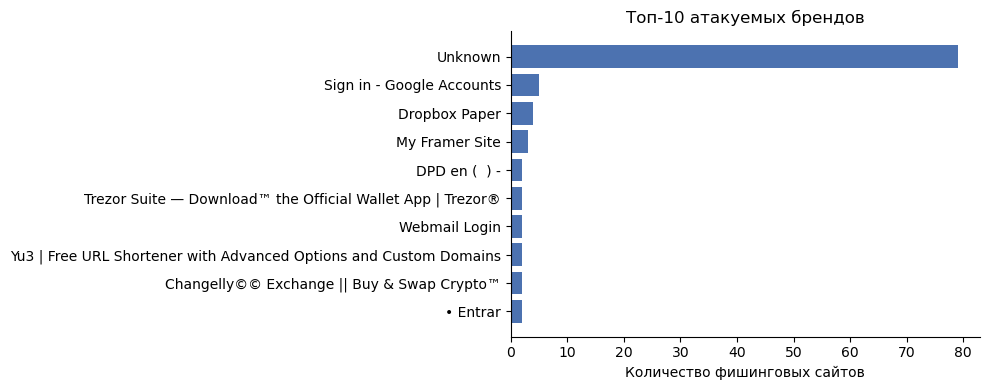

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(top10["Бренд"][::-1], top10["Количество"][::-1], color="#4c72b0")
ax.set_xlabel("Количество фишинговых сайтов")
ax.set_title("Топ-10 атакуемых брендов")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()